<div style="border-radius:10px;
            border : black solid;
            background-color: ##FFFFFF;
            font-size:160%;
            text-align: left">

<h1 style='; border:0; border-radius: 10px; text-shadow: 1px 1px black; font-weight: bold; color:#4D1873'><center> TWITTER SENTIMENT ANALYSIS ~ HATRED SPEECH RECOGNITION 😊🤬 </center></h1>

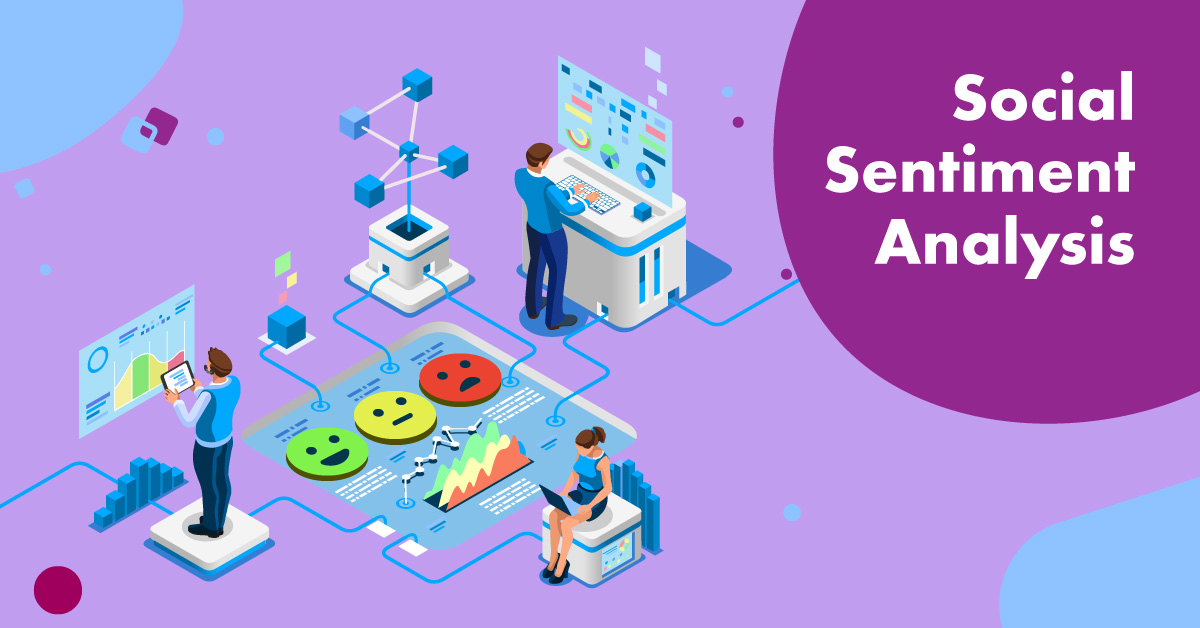

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873; font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">INTRODUCTION</p>

<div style="border-radius:5px;
            border : black solid;
            background-color: #E3E3E3;
            text-align: left">


### <mark>What is sentiment analysis?</mark> 
Sentiment analysis, also referred to as opinion mining, is an approach to natural language processing that identifies the emotional tone behind a body of text. This is a popular way for organizations to determine and categorize opinions about a product, service, or idea. It involves the use of data mining, machine learning and artificial intelligence to mine text for sentiment and subjective information.

Sentiment analysis systems help organizations gather insights from unorganized and unstructured text that comes from online sources such as emails, blog posts, support tickets, web chats, social media channels, forums and comments. Algorithms replace manual data processing by implementing rule-based, automatic or hybrid methods. Rule-based systems perform sentiment analysis based on predefined, lexicon-based rules while automatic systems learn from data with machine learning techniques. A hybrid sentiment analysis combines both approaches. In addition to identifying sentiment, opinion mining can extract the polarity (or the amount of positivity and negativity), subject and opinion holder within the text. Furthermore, sentiment analysis can be applied to varying scopes such as document, paragraph, sentence and sub-sentence levels.

### <mark>Types of sentiment analysis</mark>
Fine-grained sentiment analysis provides a more precise level of polarity by breaking it down into further categories, usually very positive to very negative. This can be considered the opinion equivalent of ratings on a 5-star scale.
Emotion detection identifies specific emotions rather than positivity and negativity. Examples could include happiness, frustration, shock, anger and sadness.
Intent-based analysis recognizes actions behind a text in addition to opinion. For example, an online comment expressing frustration about changing a battery could prompt customer service to reach out to resolve that specific issue.
Aspect-based analysis gathers the specific component being positively or negatively mentioned. For example, a customer might leave a review on a product saying the battery life was too short. Then, the system will return that the negative sentiment is not about the product as a whole, but about the battery life.
    
    

#### <mark>Reference:</mark> https://www.techtarget.com/searchbusinessanalytics/definition/opinion-mining-sentiment-mining

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">IMPORT NECESSARY LIBRARIES</p>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import model_selection, preprocessing, linear_model, metrics
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn import ensemble
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier


import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from textblob import Word
nltk.download('wordnet')

from termcolor import colored
from warnings import filterwarnings
filterwarnings('ignore')

from sklearn import set_config
set_config(print_changed_only = False)

print(colored("\nLIBRARIES WERE SUCCESFULLY IMPORTED...", color = "green", attrs = ["dark", "bold"]))

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">LOAD DATASETS</p>

In [ ]:
train_set = pd.read_csv("../input/twitter-sentiment-analysis-hatred-speech/train.csv",
                   encoding = "utf-8",
                   engine = "python",
                   header = 0)

test_set = pd.read_csv("../input/twitter-sentiment-analysis-hatred-speech/test.csv",
                   encoding = "utf-8",
                   engine = "python",
                   header = 0)

print(colored("\nDATASETS WERE SUCCESFULLY LOADED...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">The first five rows of train set</span>

In [ ]:
train_set.head(n = 5).style.background_gradient(cmap = "summer")

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">The first five rows of test set</span>

In [ ]:
test_set.head(n = 5).style.background_gradient(cmap = "summer")

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Shapes of the train and test sets</span>

In [ ]:
print("Train set shape: {} and test set shape: {}".format(train_set.shape, test_set.shape))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Get general information about train set</span>

In [ ]:
train_set.info()

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Check whether there are duplicated values</span>

In [ ]:
print("Totally there are {} duplicated values in train_set".format(train_set.duplicated().sum()))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Get the number of classes of the "label" variable of train set</span>

In [ ]:
train_set.groupby("label").count().style.background_gradient(cmap = "summer")

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">CLEAN AND PROCESS DATASET</p>

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Convert uppercase letters to lowercase letters in "tweet" columns</span>

In [ ]:
train_set["tweet"] = train_set["tweet"].apply(lambda x: " ".join(x.lower() for x in x.split()))
test_set["tweet"] = test_set["tweet"].apply(lambda x: " ".join(x.lower() for x in x.split()))

print(colored("\nCONVERTED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Delete punctuation marks from "tweet" columns</span>

In [ ]:
train_set["tweet"] = train_set["tweet"].str.replace('[^\w\s]','')
test_set["tweet"] = test_set["tweet"].str.replace('[^\w\s]','')

print(colored("\nDELETED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Delete numbers from "tweet" columns</span>

In [ ]:
train_set['tweet'] = train_set['tweet'].str.replace('\d','')
test_set['tweet'] = test_set['tweet'].str.replace('\d','')

print(colored("\n NUMBERS DELETED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Delete stopwords from "tweet" columns</span>

In [ ]:
sw = stopwords.words("english")
train_set['tweet'] = train_set['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))
test_set['tweet'] = test_set['tweet'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

print(colored("\nSTOPWORDS DELETED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Lemmatization. That is, we get the roots of the words in the "tweet" columns</span>

In [ ]:
train_set['tweet'] = train_set['tweet'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))
test_set['tweet'] = test_set['tweet'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()])) 

print(colored("\nDONE SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Drop "id" column from datasets</span>

In [ ]:
train_set = train_set.drop("id", axis = 1)
test_set = test_set.drop("id", axis = 1)

print(colored("\n'ID' COLUMNS DROPPED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Look at the latest condition of train set
</span>

In [ ]:
train_set.head(n = 10)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Look at the latest condition of test set</span>

In [ ]:
test_set.head(n = 10)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Divide datasets</span>

In [ ]:
x = train_set["tweet"]
y = train_set["label"]

train_x, test_x, train_y, test_y = model_selection.train_test_split(x, y, test_size = 0.20, shuffle = True, random_state = 11)

print(colored("\nDIVIDED SUCCESFULLY...", color = "green", attrs = ["dark", "bold"]))

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">VECTORIZE DATA</p>

### Word Embeddings or Word vectorization is a methodology in NLP to map words or phrases from vocabulary to a corresponding vector of real numbers which used to find word predictions, word similarities/semantics.

![](https://miro.medium.com/max/1400/1*SyY1GT1GvKifzpyLc18YEg.png)

#### Refence: https://towardsdatascience.com/understanding-nlp-word-embeddings-text-vectorization-1a23744f7223

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">"Count Vectors" method</span>

In [ ]:
vectorizer = CountVectorizer()
vectorizer.fit(train_x)

x_train_count = vectorizer.transform(train_x)
x_test_count = vectorizer.transform(test_x)

x_train_count.toarray()

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">"TF-IDF" method</span>

In [ ]:
tf_idf_word_vectorizer = TfidfVectorizer()
tf_idf_word_vectorizer.fit(train_x)

x_train_tf_idf_word = tf_idf_word_vectorizer.transform(train_x)
x_test_tf_idf_word = tf_idf_word_vectorizer.transform(test_x)

x_train_tf_idf_word.toarray()

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">BUILD MACHINE LEARNING MODELS</p>

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Logistic regression model with "count-vectors" method</span>

In [ ]:
log = linear_model.LogisticRegression()
log_model = log.fit(x_train_count, train_y)
accuracy = model_selection.cross_val_score(log_model,
                                           x_test_count,
                                           test_y,
                                           cv = 20).mean()

print(colored("\nLogistic regression model with 'count-vectors' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Logistic regression model with "tf-idf" method</span>

In [ ]:
log = linear_model.LogisticRegression()
log_model = log.fit(x_train_tf_idf_word, train_y)
accuracy = model_selection.cross_val_score(log_model,
                                           x_test_tf_idf_word,
                                           test_y,
                                           cv = 20).mean()

print(colored("\nLogistic regression model with 'tf-idf' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">XGBoost model with "count-vectors" method</span>

In [ ]:
xgb = XGBClassifier()
xgb_model = xgb.fit(x_train_count,train_y)
accuracy = model_selection.cross_val_score(xgb_model,
                                           x_test_count,
                                           test_y,
                                           cv = 20).mean()

print(colored("\nXGBoost model with 'count-vectors' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">XGBoost model with "tf-idf" method</span>

In [ ]:
xgb = XGBClassifier()
xgb_model = xgb.fit(x_train_tf_idf_word,train_y)
accuracy = model_selection.cross_val_score(xgb_model, 
                                           x_test_tf_idf_word, 
                                           test_y, 
                                           cv = 20).mean()

print(colored("\nXGBoost model with 'tf-idf' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;">Light GBM model with "count-vectors" method</span>

In [ ]:
lgbm = LGBMClassifier()
lgbm_model = lgbm.fit(x_train_count.astype("float64"), train_y)
accuracy = model_selection.cross_val_score(lgbm_model,
                                           x_test_count.astype("float64"),
                                           test_y,
                                           cv = 20).mean()

print(colored("\nLight GBM model with 'count-vectors' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;"> Light GBM model with "tf-idf" method</span>

In [ ]:
lgbm = LGBMClassifier()
lgbm_model = lgbm.fit(x_train_tf_idf_word,train_y)
accuracy = model_selection.cross_val_score(lgbm_model,
                                           x_test_tf_idf_word,
                                           test_y,
                                           cv = 20).mean()

print(colored("\nLight GBM model with 'tf-idf' method", color = "red", attrs = ["dark", "bold"]))
print(colored("Accuracy ratio: ", color = "red", attrs = ["dark", "bold"]), accuracy)

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;"> ROC AUC (curvature)</span>

In [ ]:
y = train_y
X = x_train_count.astype("float64")

logit_roc_auc = roc_auc_score(y, lgbm_model.predict(X))

fpr, tpr, thresholds = roc_curve(y, lgbm_model.predict_proba(X)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='AUC (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC')
plt.show()

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">ESTIMATION OVER TEST SET</p>

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;"> Look at the first 5 rows of the test set</span>

In [ ]:
test_set.head()

## <mark>Here we encode values of "tweet" column of test set with "count-vectors" method.</mark>

In [ ]:
vectorizer = CountVectorizer()
vectorizer.fit(train_x)
test_set = vectorizer.transform(test_set["tweet"])
test_set.toarray()

In [ ]:
lgbm_model.predict(test_set.astype("float"))[0:5]

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
<p style="background-color:#4D1873 ;font-family:arial;color:#FFFFFF;font-size:170%;text-align:center;border-radius:55px 1px;">VISUALIZATION WITH WORD CLOUD</p>

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image

tw_mask = np.array(Image.open('../input/masksforwordclouds/twitter_mask3.jpg'))

text = " ".join(i for i in train_set.tweet)

wc = WordCloud(background_color = "white",
               width = 600, mask = tw_mask,
               height = 600,
               contour_width = 0,
               contour_color = "red",
               max_words = 1000,
               scale = 1,
               collocations = False,
               repeat = True,
               min_font_size = 1)

wc.generate(text)

plt.figure(figsize = [15, 15])
plt.imshow(wc)
plt.axis("off")
plt.show;

### <span style = "background:#4D1873; font-size:100%; color:#fff; border-radius:0px;"> Author's message</span>

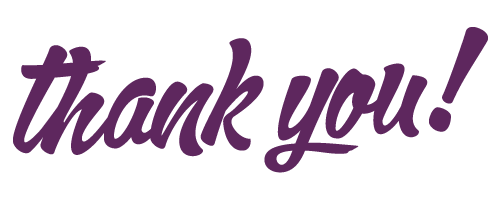